In [1]:
time_data = [
    (3.5, 2.0, 7.0), (5.0, 1.5, 6.5), (2.5, 3.0, 8.0),
    (4.0, 2.0, 6.0), (1.5, 4.5, 9.0), (3.0, 2.5, 7.5),
    (5.5, 1.0, 6.0), (2.0, 3.5, 8.5), (4.5, 2.0, 7.0),
    (3.0, 3.0, 7.5), (6.0, 1.5, 6.0), (2.5, 4.0, 8.0),
    (4.0, 2.5, 7.0), (5.0, 2.0, 6.5), (3.5, 2.5, 7.0)
]

Task1

In [2]:
low = []
moderate = []
high = []
for (study, ent, sleep) in time_data:
    if study < 3:
        low.append(study)
    elif 3 <= study <= 5:
        moderate.append(study)
    else:
        high.append(study)
print(low, moderate, high)

[2.5, 1.5, 2.0, 2.5] [3.5, 5.0, 4.0, 3.0, 4.5, 3.0, 4.0, 5.0, 3.5] [5.5, 6.0]


Task2

In [3]:
print(len(low), len(moderate), len(high))

4 9 2


Task3

In [4]:
study_minutes = [s * 60 for (s,_,_) in time_data]
print(study_minutes)

[210.0, 300.0, 150.0, 240.0, 90.0, 180.0, 330.0, 120.0, 270.0, 180.0, 360.0, 150.0, 240.0, 300.0, 210.0]


Task4

In [5]:
study_hours = [s for (s,_,_) in time_data]
entertainment_hours = [e for (_,e,_) in time_data]
sleep_hours = [sh for (_,_,sh) in time_data]

def average(lst): return sum(lst)/len(lst)
print(average(study_hours), average(entertainment_hours), average(sleep_hours))

3.7 2.5 7.166666666666667


Task5

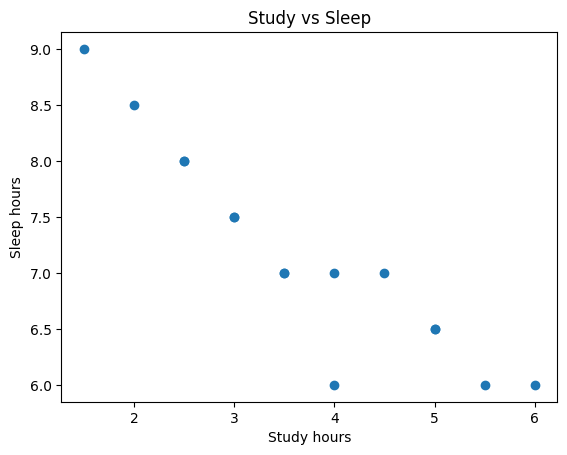

In [6]:
import matplotlib.pyplot as plt
plt.scatter(study_hours, sleep_hours)
plt.xlabel('Study hours'); plt.ylabel('Sleep hours')
plt.title('Study vs Sleep')
plt.show()

Recursion Task1

In [7]:
def sum_nested_list(nested_list):
    total = 0
    for x in nested_list:
        if isinstance(x, list): total += sum_nested_list(x)
        else: total += x
    return total

print(sum_nested_list([1,[2,[3,4],5],6,[7,8]]))

36


Recursion Task2

In [8]:
from itertools import permutations
def generate_permutations(s):
    return sorted(set(''.join(p) for p in permutations(s)))

print(generate_permutations('abc'))
print(generate_permutations('aab'))


['abc', 'acb', 'bac', 'bca', 'cab', 'cba']
['aab', 'aba', 'baa']


Recursion Task3

In [9]:
def calculate_directory_size(directory):
    total = 0
    for v in directory.values():
        if isinstance(v, dict): total += calculate_directory_size(v)
        else: total += v
    return total

directory_structure = {
    'file1.txt': 200,
    'file2.txt': 300,
    'subdir1': {
        'file3.txt': 400,
        'file4.txt': 100
    },
    'subdir2': {
        'subsubdir1': {'file5.txt': 250},
        'file6.txt': 150
    }
}
print(calculate_directory_size(directory_structure))

1400


Dynamic Programming Task1

In [10]:
def min_coins(coins, amount):
    dp = [float('inf')] * (amount+1)
    dp[0] = 0
    for c in coins:
        for i in range(c, amount+1):
            dp[i] = min(dp[i], dp[i-c] + 1)
    return dp[amount] if dp[amount]!=float('inf') else -1

print(min_coins([1,2,5], 11))

3


Dynamic Programming Task2

In [11]:
def longest_common_subsequence(s1, s2):
    n,m = len(s1), len(s2)
    dp=[[0]*(m+1) for _ in range(n+1)]
    for i in range(1,n+1):
        for j in range(1,m+1):
            if s1[i-1]==s2[j-1]: dp[i][j]=dp[i-1][j-1]+1
            else: dp[i][j]=max(dp[i-1][j],dp[i][j-1])
    return dp[n][m]

print(longest_common_subsequence('abcde','ace'))

3


Dynamic Programming Task3

In [12]:
def knapsack(weights, values, capacity):
    n=len(weights)
    dp=[[0]*(capacity+1) for _ in range(n+1)]
    for i in range(1,n+1):
        w=weights[i-1]; v=values[i-1]
        for cap in range(capacity+1):
            dp[i][cap]=dp[i-1][cap]
            if w<=cap:
                dp[i][cap]=max(dp[i][cap], dp[i-1][cap-w]+v)
    return dp[n][capacity]

print(knapsack([1,3,4,5],[1,4,5,7],7))

9
